In [44]:
import numpy as np
import pandas as pd
import cvxpy as cp
from scipy.spatial import KDTree
from scipy.interpolate import interp1d
import plotly.graph_objects as go
from scipy.interpolate import CubicSpline
from Functions.Graphs import *
from sklearn.metrics import root_mean_squared_error as RMSE
import optuna
from optuna.samplers import RandomSampler
from optuna.exceptions import TrialPruned
from numba import njit

In [45]:
path = r'ChargingResistance_SOC.csv' 
df = pd.read_csv(path)
SOC = df.iloc[:,0].values
CR = df.iloc[:,1].values
get_CR = interp1d(SOC, CR, kind='linear', bounds_error=False, fill_value="extrapolate")

path = r'DischargingResistance_SOC.csv' 
df = pd.read_csv(path)
SOC = df.iloc[:,0].values
DR = df.iloc[:,1].values
get_DR = interp1d(SOC, DR, kind='linear', bounds_error=False, fill_value="extrapolate")

path = r'OCV_SOC.csv'
df = pd.read_csv(path)
SOC = df.iloc[:,0].values
OCV = df.iloc[:,1].values
get_OCV = interp1d(SOC, OCV, kind='linear', bounds_error=False, fill_value="extrapolate")

path = r'PMEFC_eta.csv'
df = pd.read_csv(path)
PFC = df.iloc[:,0].values
ETA = df.iloc[:,1].values
get_ETAfc = interp1d(PFC, ETA, kind='linear', bounds_error=False, fill_value="extrapolate")

def GetBatterieParams(soc):
    Rbat = get_DR(soc)
    Uocv = get_OCV(soc)
    return Rbat, Uocv

def GetETAfc(pfc):
    return get_ETAfc(pfc)/100
 
def SelSampler(mode='auto'):
    if mode == 'auto':
        sampler = None
    elif mode == 'tpe':
        sampler = optuna.samplers.TPESampler(multivariate=True, n_startup_trials=10)
    elif mode == 'random':
        sampler = RandomSampler()
    return sampler

def TractionForce(v,acc):
    cr = 0.0085
    cd = 0.55
    rho = 1.225
    a = 0
    Area = 8.16
    m = 3000
    g = 9.81
    return m*g*cr*np.cos(a) + m*g*np.sin(a) + m*acc + 0.5*rho*Area*cd*(v**2)

def Preq(v, acc):
    Ft= TractionForce(v,acc)
    eta= 1
    return Ft * v / eta

def TurningSpeed(u_control_1, V_cruising, V_turning, k=0.15):
    V_turning = V_turning * 0.9
    angulo_abs = abs(u_control_1)
    speed_drop = (V_cruising - V_turning) * np.exp(-k * angulo_abs)
    return float(V_turning + speed_drop)

def get_linear_model_matrices_all(x_current, u_prev, dt, n_horizon, l=2.5):
    v = np.full(n_horizon, x_current[2])
    psi = np.full(n_horizon, x_current[3])
    a = np.full(n_horizon, u_prev[0])
    delta = np.full(n_horizon, u_prev[1])
    
    beta = np.arctan(0.5 * np.tan(delta))
    cos_psi_beta = np.cos(psi + beta)
    sin_psi_beta = np.sin(psi + beta)
    
    A_list = np.zeros((n_horizon, 4, 4))
    B_list = np.zeros((n_horizon, 4, 2))
    c_list = np.zeros((n_horizon, 4))
    
    dbeta_ddelta = 0.5 * (1 + np.tan(delta)**2) / (1 + (0.5 * np.tan(delta))**2)
    dx_ddelta = -dt * v * sin_psi_beta * dbeta_ddelta
    dy_ddelta = dt * v * cos_psi_beta * dbeta_ddelta
    dpsi_ddelta = dt * (v / l) * np.cos(beta) * dbeta_ddelta
    
    for k in range(n_horizon):
        A_list[k] = [
            [1.0, 0.0, dt * cos_psi_beta[k], -dt * v[k] * sin_psi_beta[k]],
            [0.0, 1.0, dt * sin_psi_beta[k],  dt * v[k] * cos_psi_beta[k]],
            [0.0, 0.0, 1.0,                0.0],
            [0.0, 0.0, dt * np.sin(beta[k])/l, 1.0]
        ]
        B_list[k] = [
            [0.0, dx_ddelta[k]],
            [0.0, dy_ddelta[k]],
            [dt,  0.0],
            [0.0, dpsi_ddelta[k]]
        ]
        
        x_next_nominal = np.array([
            x_current[0] + dt * v[k] * cos_psi_beta[k],
            x_current[1] + dt * v[k] * sin_psi_beta[k],
            v[k] + dt * a[k],
            psi[k] + dt * (v[k] / l) * np.sin(beta[k])
        ])
        c_list[k] = x_next_nominal - A_list[k] @ x_current - B_list[k] @ u_prev
        
    return A_list, B_list, c_list

def get_vehicle_matrices(U_DC, Q_bat, eta_dcdc=0.9, dt=1.0):
    # Q_bat is in Ah, convert to Ampere-seconds (Coulombs)
    Q_sec = Q_bat * 3600.0 
    
    # Core factor: how power affects SoC at the current bus voltage
    alpha = dt / (U_DC * Q_sec)
    
    A = np.array([
        [1.0,  alpha * eta_dcdc],
        [0.0,  1.0]
    ])
    
    Bu = np.array([
        [alpha * eta_dcdc],
        [1.0]
    ])
    
    Bv = np.array([
        [-alpha],
        [0.0]
    ])
    
    return A, Bu, Bv

def SimulateRT(dt=0.1, n_horizon=30, sim_steps=800, track_percentual=1,
               W_X=1, W_Y=1, W_speed=10, W_acc=1.5, W_delta=0.25, W_U0=1, W_U1=2,
               size=1, show=False):
    
    BreakCheck = False
    #path = r'DyntheticDataset\RaceTrack4.csv' 
    path = r'DyntheticDataset\RaceTrack5.csv' 
    try:
        df = pd.read_csv(path)
        x_mid = df['x_coords'].values[:] * size
        y_mid = df['y_coords'].values[:] * size
    except FileNotFoundError:
        theta = np.linspace(0, 2*np.pi, 200)
        x_mid = 100 * np.cos(theta) + 100
        y_mid = 100 * np.sin(theta) + 100

    track_points = np.vstack((x_mid, y_mid)).T
    track_tree = KDTree(track_points)

    dx = np.diff(x_mid)
    dy = np.diff(y_mid)
    segment_lengths = np.sqrt(dx**2 + dy**2)
    s_coor = np.insert(np.cumsum(segment_lengths), 0, 0.0)
    track_length = s_coor[-1]

    get_x_at_s = interp1d(s_coor, x_mid, kind='linear', bounds_error=False, fill_value="extrapolate")
    get_y_at_s = interp1d(s_coor, y_mid, kind='linear', bounds_error=False, fill_value="extrapolate")

    V_cruising, V_turning = 18, 6
    l = 2.5 

    s_total_traveled = 0.0
    last_current_idx = 0
    x_current = np.array([x_mid[0], y_mid[0], 0.0, 0.0])
    u_prev = np.array([0.0, 0.0])

    t_history, x_history, y_history, v_history = [0.0], [x_current[0]], [x_current[1]], [x_current[2]]
    v_ref_history, acc_history, delta_history, psi_history = [0.0], [0.0], [0.0], [0.0]
    v_horizon = [np.zeros(n_horizon+1)]
    Preq_horizon = [np.zeros(n_horizon)]
    turning_history = [0]

    t_lim = 50 * track_percentual * size
    sim_steps = int(sim_steps * track_percentual * 1.1 * size)
    
    # ==============================================================================
    # --- OPTIMIZED CVXPY PARAMETRIC SETUP (FULLY VECTORIZED PARAMETERS) ---
    # ==============================================================================
    X_cvx = cp.Variable((4, n_horizon + 1))
    U_cvx = cp.Variable((2, n_horizon))
    
    x_init_param = cp.Parameter(4)
    u_prev_param = cp.Parameter(2)
    
    # Combined horizon constraints as stacked parameters 
    # This prevents updating parameters entry-by-entry inside the loop
    x_ref_param = cp.Parameter(n_horizon)
    y_ref_param = cp.Parameter(n_horizon)
    v_ref_param = cp.Parameter(n_horizon)
    W_acc_param = cp.Parameter(nonneg=True)
    
    # Stacking A, B, and c arrays dynamically removes the 1-to-N horizon assignment loops
    A_stacked = cp.Parameter((n_horizon * 4, 4))
    B_stacked = cp.Parameter((n_horizon * 4, 2))
    c_stacked = cp.Parameter((n_horizon * 4))
    
    cost = 0
    constraints = [X_cvx[:, 0] == x_init_param]
    
    for k in range(n_horizon):
        # Extract row slices mapping cleanly across the stacked matrices
        A_k = A_stacked[k*4 : (k+1)*4, :]
        B_k = B_stacked[k*4 : (k+1)*4, :]
        c_k = c_stacked[k*4 : (k+1)*4]
        
        constraints += [X_cvx[:, k+1] == A_k @ X_cvx[:, k] + B_k @ U_cvx[:, k] + c_k]
        
        cost += W_X * cp.square(X_cvx[0, k] - x_ref_param[k])
        cost += W_Y * cp.square(X_cvx[1, k] - y_ref_param[k])
        cost += W_speed * cp.square(X_cvx[2, k] - v_ref_param[k])
        cost += W_acc_param * cp.square(U_cvx[0, k])
        cost += W_delta * cp.square(U_cvx[1, k])
        
        if k == 0:
            cost += W_U0 * cp.square(U_cvx[0, 0] - u_prev_param[0])
            cost += W_U1 * cp.square(U_cvx[1, 0] - u_prev_param[1])
        else:
            cost += W_U0 * cp.square(U_cvx[0, k] - U_cvx[0, k-1])
            cost += W_U1 * cp.square(U_cvx[1, k] - U_cvx[1, k-1])
            
        constraints += [U_cvx[0, k] >= -5.0, U_cvx[0, k] <= 3]
        constraints += [U_cvx[1, k] >= -np.deg2rad(30), U_cvx[1, k] <= np.deg2rad(30)]
        constraints += [X_cvx[2, k] >= 0.0, X_cvx[2, k] <= V_cruising]
        
    prob = cp.Problem(cp.Minimize(cost), constraints)
    # ==============================================================================

    for step in range(sim_steps):
        if step % 100 * size == 0 and show: 
            print(f'Step: {step} | Speed: {x_current[2]:.2f} m/s | Distance traveled: {s_total_traveled:.2f} / {track_length*size*track_percentual:.2f} m')
        _, current_idx = track_tree.query([x_current[0], x_current[1]])
        
        idx_diff = current_idx - last_current_idx
        if idx_diff < -len(x_mid)/2: idx_diff += len(x_mid)
        elif idx_diff > len(x_mid)/2: idx_diff -= len(x_mid)
        if idx_diff > 0:
            s_total_traveled += np.sum(segment_lengths[last_current_idx:current_idx])
        last_current_idx = current_idx

        s_projected = s_coor[current_idx]
        x_ref_horizon = np.zeros(n_horizon)
        y_ref_horizon = np.zeros(n_horizon)
        v_ref_horizon = np.zeros(n_horizon)

        u_prev_deg = np.rad2deg(u_prev[1])
        for k in range(n_horizon):
            s_projected += max(x_current[2], 1.5) * dt 
            s_wrapped = s_projected % track_length
            x_ref_horizon[k] = get_x_at_s(s_wrapped)
            y_ref_horizon[k] = get_y_at_s(s_wrapped)
            
            if s_total_traveled >= track_length * track_percentual:
                v_ref_horizon[k] = 0.0
            else:
                v_ref_horizon[k] = TurningSpeed(u_prev_deg, V_cruising, V_turning, k=0.15)
            
        A_mat, B_mat, c_mat = get_linear_model_matrices_all(x_current, u_prev, dt, n_horizon, l)

        # Update scalar parameters instantly
        W_acc_param.value = 0.0 if s_total_traveled >= track_length * track_percentual else W_acc
        x_init_param.value = x_current
        u_prev_param.value = u_prev
        x_ref_param.value = x_ref_horizon
        y_ref_param.value = y_ref_horizon
        v_ref_param.value = v_ref_horizon

        # --- INSTANT MASS ASSIGNMENT VIA TRANSFORMATION ---
        # Stacking removes the python `for k in range(n_horizon)` setter loop entirely!
        A_stacked.value = A_mat.reshape(n_horizon * 4, 4)
        B_stacked.value = B_mat.reshape(n_horizon * 4, 2)
        c_stacked.value = c_mat.flatten()

        try:
            # Native warm_start dramatically improves MOSEK performance over step updates
            # canon_backend handles problem parsing via SciPy to avoid the _cvxcore error
            prob.solve(
                solver=cp.MOSEK, 
                verbose=False, 
                warm_start=True, 
                canon_backend=cp.SCIPY_CANON_BACKEND
            )
            u_control = U_cvx[:, 0].value
            
            if u_control is None: 
                raise ValueError("Solver returned None")
                
        except Exception:
            u_control = np.array([0.0, u_prev[1]])


        beta_sim = np.arctan(0.5 * np.tan(u_control[1]))
        x_next = x_current[0] + dt * (x_current[2] * np.cos(x_current[3] + beta_sim))
        y_next = x_current[1] + dt * (x_current[2] * np.sin(x_current[3] + beta_sim))
        v_next = x_current[2] + dt * u_control[0]
        psi_next = x_current[3] + dt * ((x_current[2] / l) * np.sin(beta_sim))
        
        turning = abs(u_control[1]) >= np.deg2rad(4.5)
        x_current = np.array([x_next, y_next, v_next, psi_next])
        u_prev = u_control.copy()

        #print(x_current[2], X_cvx[2].value[:4])
        v_h = X_cvx[2].value[1:]
        acc_h = U_cvx[0].value

        p_horizon = Preq(v_h,acc_h)
        
        
        t_history.append((step + 1) * dt)
        x_history.append(x_current[0])
        y_history.append(x_current[1])
        v_history.append(x_current[2])
        v_horizon.append(X_cvx.value[2])
        Preq_horizon.append(p_horizon)
        v_ref_history.append(v_ref_horizon[0])
        acc_history.append(u_control[0])
        delta_history.append(np.rad2deg(u_control[1]))
        psi_history.append(np.rad2deg(x_current[3]))
        turning_history.append(1 if turning else 0)
        
        delta_check = np.abs(np.array(delta_history))
        window = int(5/dt)
        Vref_mean = abs(np.mean(np.array(v_ref_history[-window:])))
        V_mean = abs(np.mean(np.array(v_history[-window:])))
        acc_mean = abs(np.mean(np.array(acc_history[-window:])))

        if len(delta_check[delta_check > 26.5]) > 10 :
            BreakCheck = True
            if show: print('Angle Break')
            break
        if s_total_traveled >= track_length * track_percentual * 1.1:
            BreakCheck = True
            if show: print('Length Break')
            break
        elif s_total_traveled >= track_length * track_percentual and x_current[2] < 0.9:
            if show: print('Completed')
            break
        elif t_history[-1] > t_lim:
            BreakCheck = True
            if show: print('Time Break')
            break
        elif t_history[-1] > t_lim and acc_mean < 0.1 and V_mean > 0.9:
            BreakCheck = True
            if show: print('Time and Speed Break')
            break
        elif Vref_mean < 0.01 and acc_mean < 0.1 and x_current[2] > 0.9:
            BreakCheck = True
            if show: print('Vref and Acc Break')
            break
    
    if show: 
        print(f'Time: {t_history[-1]} | Speed: {x_current[2]:.2f} m/s | Distance traveled: {s_total_traveled:.2f} / {track_length*size*track_percentual:.2f} m')
    t_history = np.array(t_history)
    score = RMSE(np.array(v_ref_history)[t_history < t_lim], np.array(v_history)[t_history < t_lim])
    turning_history.append(1 if turning else 0)


    #df_Vhorizon = pd.DataFrame(v_horizon)
    #df_Vhorizon.iloc[:,0] = t_history
    #names = ['time'] + [f'{i}' for i in range(1,(n_horizon+1))]
    #df_Vhorizon.columns = names

    v_horizon = np.array(v_horizon).T

    df_Vhorizon = pd.DataFrame()
    df_Vhorizon['time'] = t_history
    for i in range(len(v_horizon)):
        df_Vhorizon[f'{i}'] = v_horizon[i]

    return score, BreakCheck, [t_history, v_history, acc_history, delta_history, turning_history, x_history, y_history, x_mid, y_mid, psi_history, v_ref_history, Preq_horizon, df_Vhorizon]

In [ ]:

def objective(trial):
    W_X = trial.suggest_float('W_X', 1, 30,step=0.25)
    W_Y = trial.suggest_float('W_Y', 1, 30,step=0.25)
    W_speed = trial.suggest_float('W_speed', 1, 20,step=0.25)
    W_acc = trial.suggest_float('W_acc'    , 1, 30,step=0.25)
    W_delta = trial.suggest_float('W_delta', 0.25, 15,step=0.25)
    W_U0 = trial.suggest_float('W_U0'      , 1, 30,step=0.25)
    W_U1 = trial.suggest_float('W_U1'      , 0.25, 20,step=0.25)
    
    score,BreakCheck,_ = SimulateRT(dt=0.1, n_horizon=30, sim_steps=800,track_percentual=0.9,
                                    W_X=W_X, W_Y=W_Y, W_speed=W_speed, W_acc=W_acc, W_delta=W_delta,
                                    W_U0=W_U0, W_U1=W_U1, size=1, show=False)
    if BreakCheck:
        raise TrialPruned()
    
    return score

study = optuna.create_study(
    direction='minimize',
    sampler=SelSampler(mode='auto'),
    #pruner=pruner,
    #storage="sqlite:///" + f'Optuna/RT.db', study_name=f'P{0}'
    )

study.optimize(objective, n_trials=50)
best_params = study.best_params
params = list(best_params.values())
print('Erro:', study.best_value, 'parameters: ', params)


Erro: 3.713029098148217 parameters:  [1.0, 5.75, 14.5, 11.0, 12.0, 16.0, 17.0]\
Erro: 3.6820291798414653 parameters:  [2.0, 7.5, 18.0, 12.5, 9.5, 23.25, 12.75]


In [46]:
if 'params' in globals(): params = params
else: params = [2.0, 7.5, 18.0, 12.5, 9.5, 23.25, 12.75]
W_X,W_Y,W_speed,W_acc,W_delta,W_U0,W_U1 =  params

score,BreakCheck,data_sim = SimulateRT(dt=0.1, n_horizon=30, sim_steps=1e5,track_percentual=1,
                                    W_X=W_X, W_Y=W_Y, W_speed=W_speed, W_acc=W_acc, W_delta=W_delta,
                                    W_U0=W_U0, W_U1=W_U1, size=1, show=True)
[t_history, v_history, acc_history, delta_history, turning_history, x_history, y_history, x_mid, y_mid, psi_history,
  v_ref_history, Preq_horizon, df_Vhorizon] = data_sim

Step: 0 | Speed: 0.00 m/s | Distance traveled: 0.00 / 1177.07 m
Step: 100 | Speed: 15.41 m/s | Distance traveled: 82.48 / 1177.07 m
Step: 200 | Speed: 14.14 m/s | Distance traveled: 207.38 / 1177.07 m
Step: 300 | Speed: 7.33 m/s | Distance traveled: 310.45 / 1177.07 m
Step: 400 | Speed: 15.33 m/s | Distance traveled: 428.28 / 1177.07 m
Step: 500 | Speed: 9.22 m/s | Distance traveled: 582.04 / 1177.07 m
Time Break
Time: 50.1 | Speed: 9.18 m/s | Distance traveled: 582.63 / 1177.07 m


In [47]:
ySeries=[v_ref_history, v_history, acc_history, delta_history][:]
xSeries=[t_history for i in range(len(ySeries))][:]
names = ['Reference Speed (m/s)', 'Current Speed (m/s)',
        'Acceleration (m/s²)', 'Stirring Angle (deg)',][:]
data = [x_mid, y_mid, x_history,y_history, t_history, delta_history, psi_history, v_history]

PlotSeriesPLY(xSeries,ySeries,names,title=f'Parameters Over Time|RMSE: {score}')
#PlotSeriesDifScalesPLY(xSeries,ySeries,names,title=f'Parameters Over Time|RMSE: {score}')
PlotMPCTracksPLY(data,width=800,height=500)

In [28]:
def SimulateEMS(Preq_horizon_raw, dt=1.0, n_horizon=3,
                W_H2=1, W_SoC=1.0, W_smooth=1.0):
    # --- Downsample the 0.1s vehicle trajectory data to 1.0s intervals ---
    Preq_ems_input = []
    for step_1s in range(len(Preq_horizon_raw)):
        if step_1s % 10 == 0:
            forecast_vector_30points = Preq_horizon_raw[step_1s]
            #forecast_3points_1s = forecast_vector_30points[::10]
            forecast_3points_1s = forecast_vector_30points[[9, 19, 29]]
            Preq_ems_input.append(forecast_3points_1s)
            
    Preq_ems_input = np.array(Preq_ems_input) 
    sim_steps = len(Preq_ems_input)

    # --- Power Sources & Vehicle Constants (From Article Table 1) ---
    Q_bat = 90.0        # Battery Capacity (Ah)
    eta_dcdc = 1      # Unidirectional DC/DC Converter Efficiency
    Q_sec = Q_bat * 3600.0 

    rho_H2 = 120 * 1e6
    
    # --- Tuning Weights ---
    #W_H2 = 1.0   # Linear usage cost
    #W_SoC = 10000.0     # High penalty to force battery charge sustainability
    #W_smooth = 10.0     # Rate protection penalty
    
    SOC_i = 0.6         
    Pfc_i = 0        # Start with a small active baseline to ease initial step optimization

    x_current = np.array([SOC_i, Pfc_i])
    
    t_history, SOC_history, Pfc_history = [0.0], [x_current[0]], [x_current[1]]
    cur_history = [0.0]
    Preq_history, P_batL_history, P_batU_history = [0], [0], [0]
    dPfc_history, P_bat_history, U_DC_history = [0], [0], [0]

    #R_bat, U_ocv = GetBatterieParams(x_current[0])

    # ==============================================================================
    # --- FIXED CVXPY COMPLIANT SETUP (ELEMENT-SPECIFIC ALGEBRA) ---
    # ==============================================================================
    X_soc = cp.Variable(n_horizon + 1)
    X_pfc = cp.Variable(n_horizon + 1)
    U_dpfc = cp.Variable(n_horizon)      

    # Numerical scalar parameters (Safely bypassing the variable matrix DPP restriction)
    soc_init_param = cp.Parameter()
    pfc_init_param = cp.Parameter()
    P_req_param = cp.Parameter(n_horizon)  
    alpha_param = cp.Parameter() # Dynamic factor updated via lookup loop each step

    I_bat_param = cp.Parameter()
    P_batL_param = cp.Parameter()
    P_batU_param = cp.Parameter()

    cost = 0
    constraints = [
        X_soc[0] == soc_init_param,
        X_pfc[0] == pfc_init_param
    ]

    constraints += [
            I_bat_param >= -250.0,  # Battery current limit (A)
            I_bat_param <=  350.0,  # Battery current limit (A)
        ]

    for k in range(n_horizon):
        # Explicit element-by-element linear tracking updates matching Equation 35/38
        constraints += [
            X_soc[k+1] == X_soc[k] + alpha_param * eta_dcdc * X_pfc[k] \
                                   + alpha_param * eta_dcdc * U_dpfc[k] \
                                   - alpha_param * P_req_param[k],
            
            X_pfc[k+1] == X_pfc[k] + U_dpfc[k]
        ]

        # Operational limits constraints
        constraints += [
            X_pfc[k+1] >=  0.0,       # Min FC Power (kW)
            X_pfc[k+1] <= 60.0,      # Max FC Power (kW)
            U_dpfc[k]  >= -1.0,       # Rate limit bounds (kW/s)
            U_dpfc[k]  <=  1.0,        
            X_soc[k+1] >=  0.3,       # SoC tracking bounds
            X_soc[k+1] <=  0.9,

            #I_bat_param >= -250.0,  # Battery current limit (A)
            #I_bat_param <=  350.0,  # Battery current limit (A)
            #P_req_param[k] - X_pfc[k] >= P_batL_param,  # Battery power lower limit (kW)
            #P_req_param[k] - X_pfc[k] <= P_batU_param
        ]
        
        # Costs
        C_H2  = W_H2 * X_pfc[k+1] * 1000 * dt / (GetETAfc(x_current[1]) * rho_H2)  # Hydrogen consumption cost in kg
        
        #cost += W_H2 * X_pfc[k+1]   
        
        #cost  += C_H2           
        cost += W_SoC * cp.square(X_soc[k+1] - 0.6)      
        #cost += W_smooth * cp.square(U_dpfc[k])            

    prob = cp.Problem(cp.Minimize(cost), constraints)

    # ==============================================================================
    # --- EXECUTION SIMULATION LOOP ---
    # ==============================================================================
    print("--- Diagnostics Start ---")
    for step in range(sim_steps):
        horizon_req = Preq_ems_input[step]
        if len(horizon_req) < n_horizon:
            horizon_req = np.pad(horizon_req, (0, n_horizon - len(horizon_req)), 'edge')

        # Convert Watts from vehicle model directly to kW
        horizon_req_kw = horizon_req / 1000.0

        current_soc = x_current[0]
        R_bat, U_ocv = GetBatterieParams(current_soc)
            

        try:
            prob.solve(solver=cp.MOSEK, warm_start=True)
            u_control = float(U_dpfc[0].value)
            if U_dpfc[0].value is None: raise ValueError
        except Exception:
            u_control = 0.0  

        # --- Nonlinear Plant Physics Update ---
        P_fc_actual = float(x_current[1] + u_control)
        #print(f'{x_current[1]:.2f} + {u_control:.2f}')
        P_bat_actual = float(horizon_req_kw[0] - P_fc_actual * eta_dcdc)
        
        P_bat_watts = P_bat_actual * 1000.0
        inside_sqrt = U_ocv**2 - 4.0 * R_bat * P_bat_watts
        inside_sqrt = max(0.01, inside_sqrt)

        I_bat_actual = (U_ocv - np.sqrt(inside_sqrt)) / (2.0 * R_bat) 

        P_bat_min_kw = R_bat * (-200.0**2) / 1000.0
        P_bat_max_kw = R_bat * (300.0**2) / 1000.0

        U_DC_true = U_ocv - I_bat_actual * R_bat 

        I_bat_param.value = I_bat_actual

        alpha_val = dt / (U_DC_true * Q_sec)
        soc_init_param.value = float(x_current[0])
        pfc_init_param.value = float(x_current[1])
        alpha_param.value = float(alpha_val)
        P_req_param.value = horizon_req_kw.flatten()
        P_batL_param.value = float(P_bat_min_kw)
        P_batU_param.value = float(P_bat_max_kw)

        soc_next = current_soc - (I_bat_actual * dt) / Q_sec
        soc_next = np.clip(soc_next, 0.0, 1.0)

        x_current = np.array([soc_next, P_fc_actual])

        t_history.append((step + 1) * dt)
        SOC_history.append(x_current[0])
        Preq_history.append(horizon_req_kw[0])
        Pfc_history.append(x_current[1])
        cur_history.append(I_bat_actual)
        dPfc_history.append(u_control)
        P_bat_history.append(P_bat_actual)
        P_batL_history.append(P_bat_min_kw)
        P_batU_history.append(P_bat_max_kw)
        U_DC_history.append(U_DC_true)

        if step % 15 ==0:
        #if step<5:
            print(f"Step {step} | Preq: {horizon_req_kw[0]:.2f} kW | ",
                  f"Pfc: {x_current[1]:.2f} kW |  Pbat: {P_bat_actual:.2f} kW | dPfc: {u_control:.2f} kW",
                  f"| Solver Status: {prob.status}"
                  )

    print("--- Diagnostics End ---\n")

    return (np.array(t_history), np.array(cur_history), np.array(SOC_history),
            np.array(Preq_history), np.array(Pfc_history), 
            np.array(dPfc_history), np.array(P_bat_history), np.array(U_DC_history))

Preq_horizon_data = data_sim[11]
t_ems, cur_ems, soc_ems, preq_ems, pfc_ems, dpfc_ems, pbat_ems, udc_ems = SimulateEMS(Preq_horizon_data[1:], dt=1.0, n_horizon=3,
                W_H2=1, W_SoC=111, W_smooth=0.01)

--- Diagnostics Start ---
Step 0 | Preq: 27.82 kW |  Pfc: 0.00 kW |  Pbat: 27.82 kW | dPfc: 0.00 kW | Solver Status: None
Step 15 | Preq: 2.54 kW |  Pfc: 4.68 kW |  Pbat: -2.14 kW | dPfc: 0.19 kW | Solver Status: optimal
Step 30 | Preq: -0.11 kW |  Pfc: 7.36 kW |  Pbat: -7.47 kW | dPfc: 0.17 kW | Solver Status: optimal
Step 45 | Preq: -129.57 kW |  Pfc: 9.83 kW |  Pbat: -139.39 kW | dPfc: 0.16 kW | Solver Status: optimal
--- Diagnostics End ---



In [30]:
ySeries = [preq_ems, pfc_ems, pbat_ems,soc_ems]
xSeries = [t_ems for i in range(len(ySeries))]
names = ['Preq (kW)', 'Pfc (kW)', 'Pbat (kW)','SOC']
PlotSeriesPLY(xSeries,ySeries,names)


-212.56993715339948


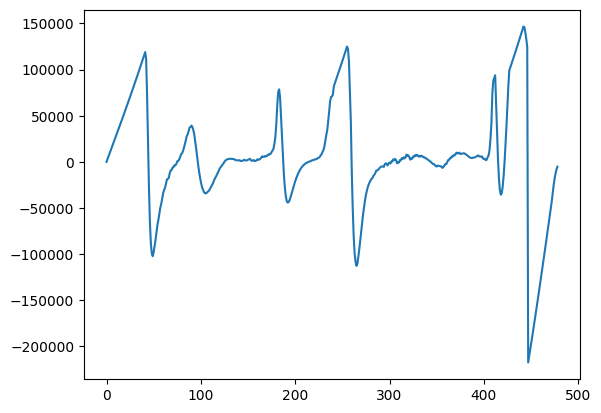

In [22]:
preq = pd.DataFrame(Preq_horizon_data)
preq = preq.iloc[:,0].values
print(np.min(cur_ems))
plt.plot(preq)

In [41]:
import io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Load your CSV data
csv_data = """SEG.;START X;START Y;END X;END Y;WIDTH 1;WIDTH 2;LENGTH;CENTRE X;CENTRE Y;RADIUS
1;225;0;260;35;0;0;54.9779;225;35;35
2;260;35;260;85;0;0;50;;;
3;260;85;235;110;0;0;39.2699;235;85;25
4;235;110;185.131;110;0;0;49.869;;;
5;185.131;110;145.0057;89.8323;0;0;46.5741;185.131;60;50
6;145.0057;89.8323;145.1891;90.0789;0;0;0.3073;;;
7;145.1891;90.0789;136.4272;70.7373;0;0;21.3965;185.3143;60.2466;50
8;136.4272;70.7373;134.3937;61.2608;0;0;9.6922;;;
9;134.3937;61.2608;114.8388;45.4571;0;0;27.1882;114.8388;65.4571;20
10;114.8388;45.4571;114.02;45.4571;0;0;0.8188;;;
11;114.02;45.4571;103.6574;48.3511;0;0;10.8933;114.02;65.4571;20
12;103.6574;48.3511;83.6857;60.4497;0;0;23.3504;;;
13;83.6857;60.4497;68.3486;100.6147;0;0;46.2956;101.8204;90.3852;35
14;68.3486;100.6147;115.4611;254.7705;0;0;161.1943;;;
15;115.4611;254.7705;81.9894;300;0;0;65.3589;81.9894;265;35
16;81.9894;300;35;300;0;0;46.9894;;;
17;35;300;0;265;0;0;54.9779;35;265;35
18;0;265;0;200;0;0;65;;;
19;0;200;0;50;0;0;150;;;
20;0;50;50;0;0;0;78.5398;50;50;50
21;50;0;225;0;0;0;175;;;
"""

df = pd.read_csv(io.StringIO(csv_data), sep=";")

# 2. Compute cumulative tracking thresholds
df["CUM_START"] = df["LENGTH"].cumsum().shift(1, fill_value=0.0)
df["CUM_END"] = df["LENGTH"].cumsum()
total_length = df["CUM_END"].iloc[-1]


# 3. Function to sample a point at any target distance 's' along the path
def get_point_at_distance(s, dataframe):
    # Handle floating point boundary conditions at the absolute end
    if s >= total_length:
        s = total_length - 1e-9

    # Locate the active segment
    seg = dataframe[(dataframe["CUM_START"] <= s) & (dataframe["CUM_END"] > s)]
    if seg.empty:
        seg = dataframe.iloc[-1:]

    row = seg.iloc[0]
    segment_s = s - row["CUM_START"]
    fraction = segment_s / row["LENGTH"]

    x1, y1 = row["START X"], row["START Y"]
    x2, y2 = row["END X"], row["END Y"]

    # Linear interpolation for straight lines
    if pd.isna(row["RADIUS"]) or row["RADIUS"] == 0:
        x = x1 + fraction * (x2 - x1)
        y = y1 + fraction * (y2 - y1)
    # Angular interpolation for arcs
    else:
        cx, cy = row["CENTRE X"], row["CENTRE Y"]
        r = row["RADIUS"]

        theta1 = np.arctan2(y1 - cy, x1 - cx)
        theta2 = np.arctan2(y2 - cy, x2 - cx)
        angular_length = row["LENGTH"] / r

        # Solve direction matching (Counter-Clockwise vs Clockwise)
        diff_ccw = (theta2 - theta1) % (2 * np.pi)
        diff_cw = (theta1 - theta2) % (2 * np.pi)

        if abs(diff_ccw - angular_length) < 1e-2:
            theta = theta1 + fraction * diff_ccw
        elif abs(diff_cw - angular_length) < 1e-2:
            theta = theta1 - fraction * diff_cw
        else:
            if abs(diff_ccw - angular_length) < abs(diff_cw - angular_length):
                theta = theta1 + fraction * diff_ccw
            else:
                theta = theta1 - fraction * diff_cw

        x = cx + r * np.cos(theta)
        y = cy + r * np.sin(theta)

    return x, y


# 4. Set the number of equidistant points you want
n_points = 2000  # Change this value to get more or fewer points
target_distances = np.linspace(0, total_length, n_points)

# Extract coordinates
equidistant_points = [
    get_point_at_distance(s, df) for s in target_distances
]
points_x, points_y = zip(*equidistant_points)
PlotPLY(x=points_x,y=points_y)


In [43]:
df_new = pd.DataFrame({
    "x_coords": points_x,"y_coords": points_y})
df_new.to_csv(r'DyntheticDataset\RaceTrack5.csv', index=False)